Math for Machine Learning

Single Layer Perceptron — Classification & Regression

In [53]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_diabetes, load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier, MLPRegressor

from slp_classifier import SimpleSLPClassifier
from slp_regressor import SimpleSLPRegressor

Regression Model

SimpleSLPRegressor  R²: 0.4792
Sklearn MLPRegressor    R²: 0.1490
(R² computed on standardised targets — scale-invariant, so the value is identical to what you would get on the original scale)


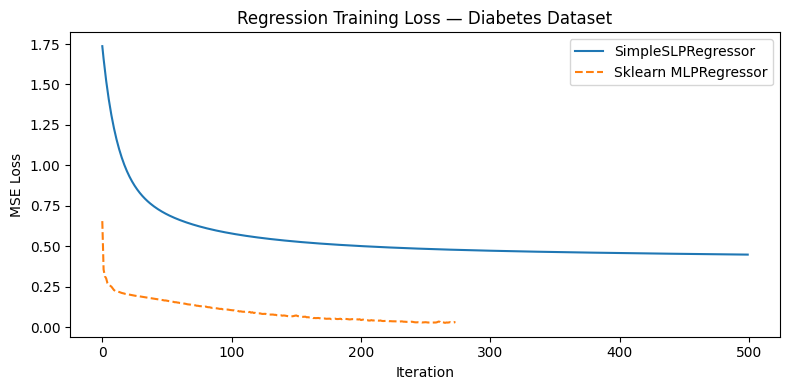

In [54]:
# Load and split
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features and target (important for neural network convergence)
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# Fit our implementation
our_reg = SimpleSLPRegressor(hidden_layer_sizes=(64,), activation='relu', learning_rate=0.01, max_iter=500, random_state=42)
our_reg.fit(X_train, y_train_scaled)
r2_our = our_reg.score(X_test, y_test_scaled)

# Fit sklearn MLPRegressor with matching hyperparameters
sklearn_reg = MLPRegressor(hidden_layer_sizes=(64,), activation='relu', learning_rate_init=0.01, max_iter=500, random_state=42)
sklearn_reg.fit(X_train, y_train_scaled)
r2_sklearn = sklearn_reg.score(X_test, y_test_scaled)

print(f'SimpleSLPRegressor  R²: {r2_our:.4f}')
print(f'Sklearn MLPRegressor    R²: {r2_sklearn:.4f}')
print('(R² computed on standardised targets — scale-invariant, so the value is identical to what you would get on the original scale)')

# Plot training loss curves
plt.figure(figsize=(8, 4))
plt.plot(our_reg.loss_curve_, label='SimpleSLPRegressor')
plt.plot(sklearn_reg.loss_curve_, label='Sklearn MLPRegressor', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Regression Training Loss — Diabetes Dataset')
plt.legend()
plt.tight_layout()
plt.show()

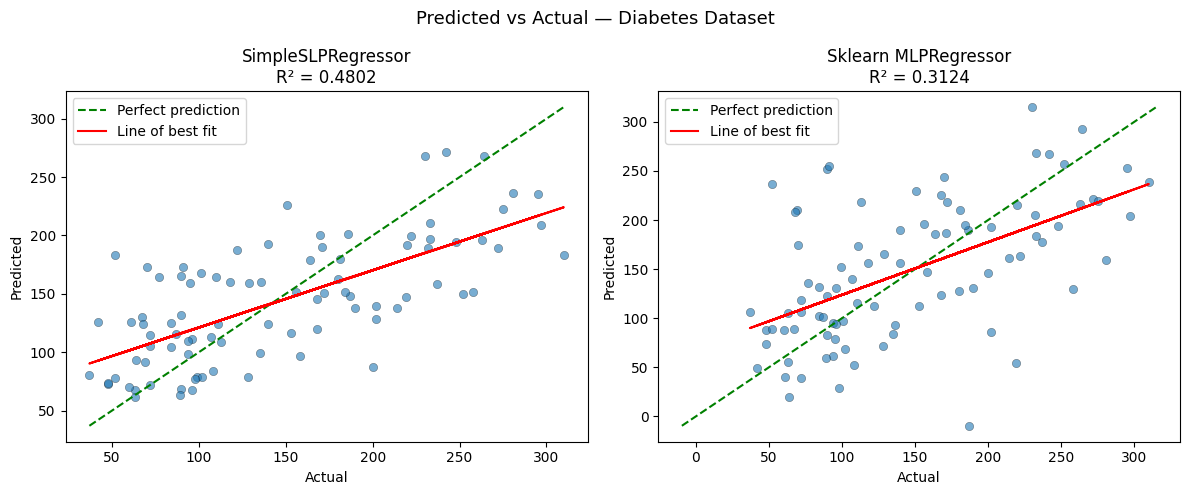

In [55]:
# Predicted vs Actual — inverse transform back to original scale for interpretability
y_pred_our = scaler_y.inverse_transform(our_reg.predict(X_test).reshape(-1, 1)).ravel()
y_pred_sklearn = scaler_y.inverse_transform(sklearn_reg.predict(X_test).reshape(-1, 1)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, label in zip(axes, [y_pred_our, y_pred_sklearn], ['SimpleSLPRegressor', 'Sklearn MLPRegressor']):
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidths=0.3)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'g--', linewidth=1.5, label='Perfect prediction')
    m, b = np.polyfit(y_test, y_pred, 1)
    ax.plot(y_test, m * y_test + b, 'r-', linewidth=1.5, label='Line of best fit')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{label}\nR² = {round(float(np.corrcoef(y_test, y_pred)[0,1]**2), 4)}')
    ax.legend()

plt.suptitle('Predicted vs Actual — Diabetes Dataset', fontsize=13)
plt.tight_layout()
plt.show()

=== Error Metrics (original scale) ===


,SimpleSLPRegressor,Sklearn MLPRegressor
MSE,2759.2523,4508.7005
RMSE,52.5286,67.1469
MAE,43.1697,51.6058
R²,0.4802,0.3124


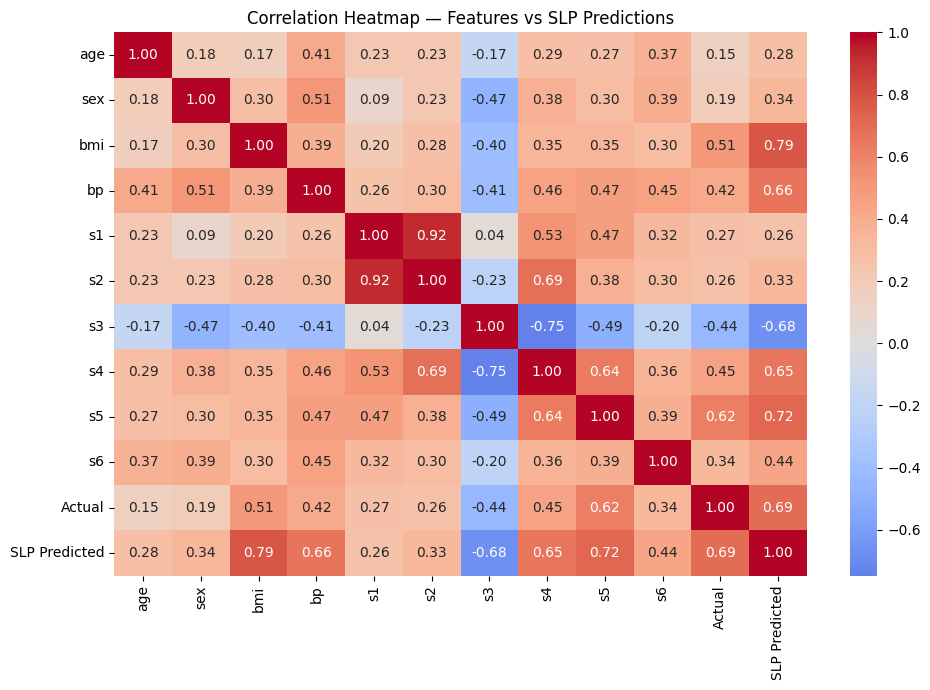

In [56]:
def error_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {'MSE': round(mse, 4), 'RMSE': round(np.sqrt(mse), 4), 'MAE': round(mean_absolute_error(y_true, y_pred), 4), 'R²': round(float(np.corrcoef(y_true, y_pred)[0,1]**2), 4)}

metrics_df = pd.DataFrame({'SimpleSLPRegressor': error_metrics(y_test, y_pred_our), 'Sklearn MLPRegressor': error_metrics(y_test, y_pred_sklearn)})
print("=== Error Metrics (original scale) ===")
display(metrics_df)

diabetes = load_diabetes()
feature_names = diabetes.feature_names
X_test_original = scaler_X.inverse_transform(X_test)

corr_data = pd.DataFrame(X_test_original, columns=feature_names)
corr_data['Actual'] = y_test
corr_data['SLP Predicted'] = y_pred_our

plt.figure(figsize=(10, 7))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Features vs SLP Predictions')
plt.tight_layout()
plt.show()

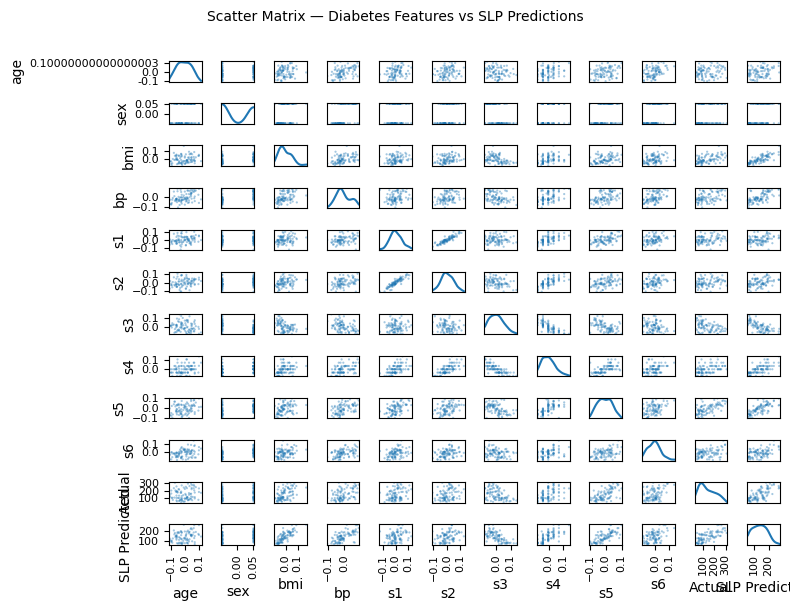

In [57]:
warnings.filterwarnings('ignore')

pd.plotting.scatter_matrix(corr_data, figsize=(8, 6), diagonal='kde', alpha=0.4, s=10)
plt.suptitle('Scatter Matrix — Diabetes Features vs SLP Predictions', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

warnings.filterwarnings('default')

=== Error Metrics — California Housing (median house value, $100k) ===


,SimpleSLPRegressor,Sklearn MLPRegressor
MSE,0.5965,0.3127
RMSE,0.7723,0.5592
MAE,0.5648,0.3750
R²,0.5450,0.7616


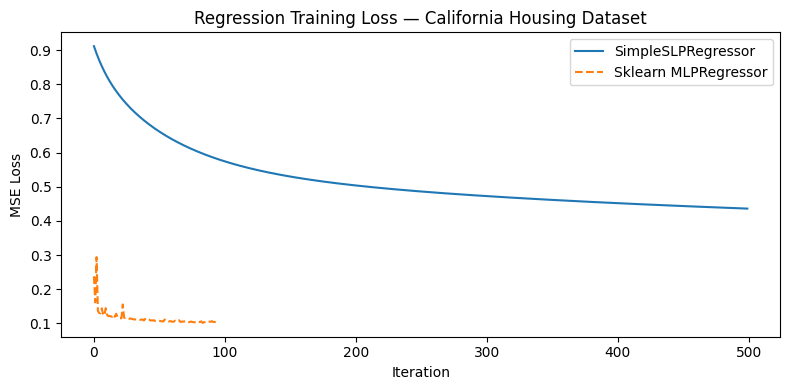

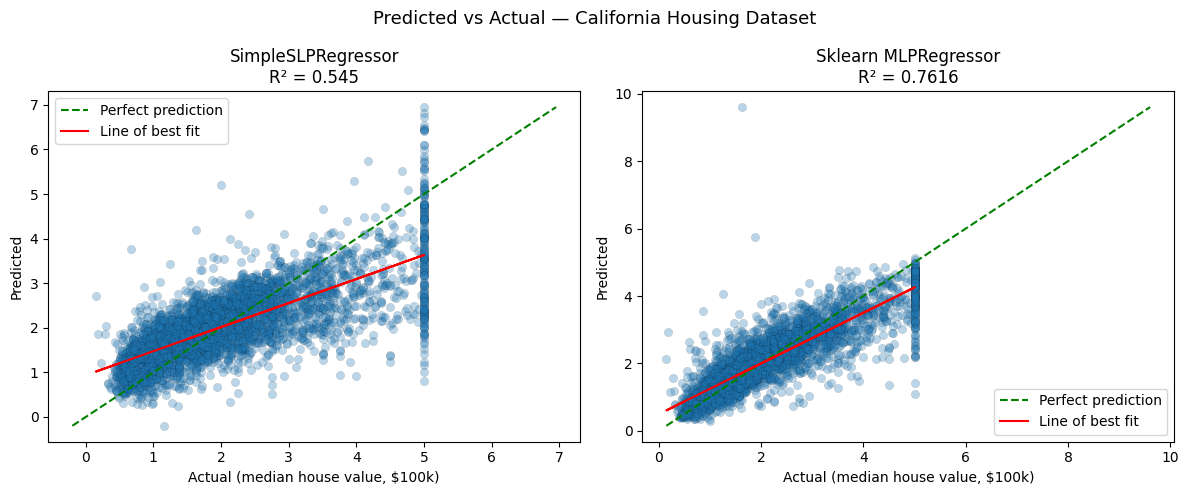

In [58]:
# test on another dataset to compare implementation
# Load California Housing — 20,640 samples, 8 features, predict median house value
cal = fetch_california_housing()
X_cal, y_cal = cal.data, cal.target

X_cal_train, X_cal_test, y_cal_train, y_cal_test = train_test_split(X_cal, y_cal, test_size=0.2, random_state=42)

scaler_Xc = StandardScaler()
X_cal_train = scaler_Xc.fit_transform(X_cal_train)
X_cal_test = scaler_Xc.transform(X_cal_test)

scaler_yc = StandardScaler()
y_cal_train_scaled = scaler_yc.fit_transform(y_cal_train.reshape(-1, 1)).ravel()
y_cal_test_scaled = scaler_yc.transform(y_cal_test.reshape(-1, 1)).ravel()

# Fit our implementation
our_cal = SimpleSLPRegressor(hidden_layer_sizes=(64,), activation='relu', learning_rate=0.01, max_iter=500, random_state=42)
our_cal.fit(X_cal_train, y_cal_train_scaled)
r2_our_cal = our_cal.score(X_cal_test, y_cal_test_scaled)

# Fit sklearn MLPRegressor with matching hyperparameters
sklearn_cal = MLPRegressor(hidden_layer_sizes=(64,), activation='relu', learning_rate_init=0.01, max_iter=500, random_state=42)
sklearn_cal.fit(X_cal_train, y_cal_train_scaled)
r2_sklearn_cal = sklearn_cal.score(X_cal_test, y_cal_test_scaled)

# Error metrics table
y_pred_cal_our = scaler_yc.inverse_transform(our_cal.predict(X_cal_test).reshape(-1, 1)).ravel()
y_pred_cal_sklearn = scaler_yc.inverse_transform(sklearn_cal.predict(X_cal_test).reshape(-1, 1)).ravel()
y_cal_test_orig = scaler_yc.inverse_transform(y_cal_test_scaled.reshape(-1, 1)).ravel()

metrics_cal = pd.DataFrame({
    'SimpleSLPRegressor': error_metrics(y_cal_test_orig, y_pred_cal_our),
    'Sklearn MLPRegressor': error_metrics(y_cal_test_orig, y_pred_cal_sklearn)
})
print("=== Error Metrics — California Housing (median house value, $100k) ===")
display(metrics_cal)

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(our_cal.loss_curve_, label='SimpleSLPRegressor')
plt.plot(sklearn_cal.loss_curve_, label='Sklearn MLPRegressor', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Regression Training Loss — California Housing Dataset')
plt.legend()
plt.tight_layout()
plt.show()

# Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, label in zip(axes, [y_pred_cal_our, y_pred_cal_sklearn], ['SimpleSLPRegressor', 'Sklearn MLPRegressor']):
    ax.scatter(y_cal_test_orig, y_pred, alpha=0.3, edgecolors='k', linewidths=0.2)
    lims = [min(y_cal_test_orig.min(), y_pred.min()), max(y_cal_test_orig.max(), y_pred.max())]
    ax.plot(lims, lims, 'g--', linewidth=1.5, label='Perfect prediction')
    m, b = np.polyfit(y_cal_test_orig, y_pred, 1)
    ax.plot(y_cal_test_orig, m * y_cal_test_orig + b, 'r-', linewidth=1.5, label='Line of best fit')
    ax.set_xlabel('Actual (median house value, $100k)')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{label}\nR² = {round(float(np.corrcoef(y_cal_test_orig, y_pred)[0,1]**2), 4)}')
    ax.legend()

plt.suptitle('Predicted vs Actual — California Housing Dataset', fontsize=13)
plt.tight_layout()
plt.show()

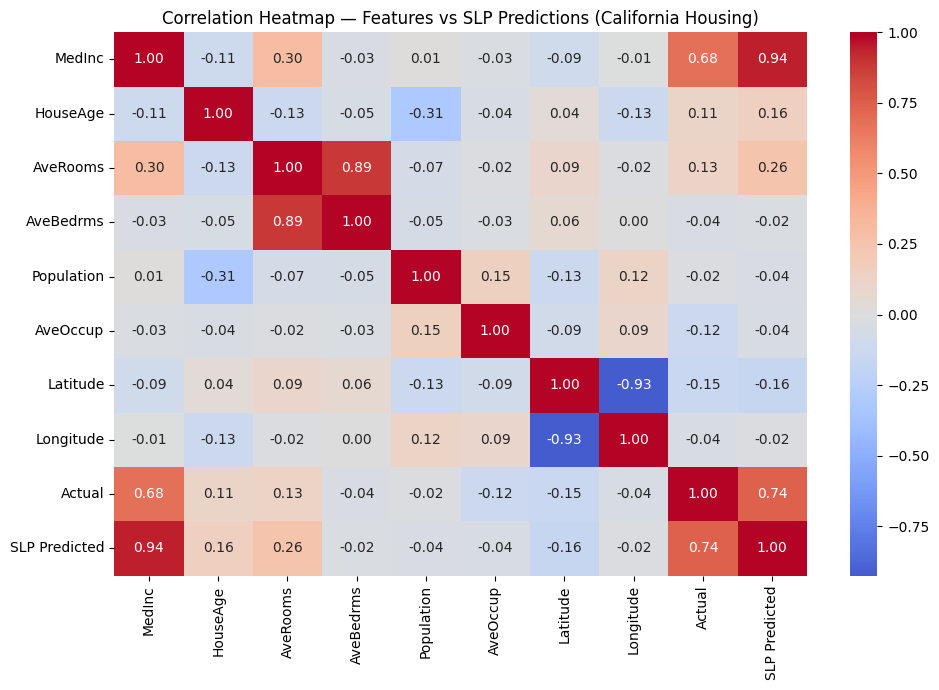

In [59]:
X_cal_test_orig = scaler_Xc.inverse_transform(X_cal_test)

corr_cal = pd.DataFrame(X_cal_test_orig, columns=cal.feature_names)
corr_cal['Actual'] = y_cal_test_orig
corr_cal['SLP Predicted'] = y_pred_cal_our

plt.figure(figsize=(10, 7))
sns.heatmap(corr_cal.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Features vs SLP Predictions (California Housing)')
plt.tight_layout()
plt.show()

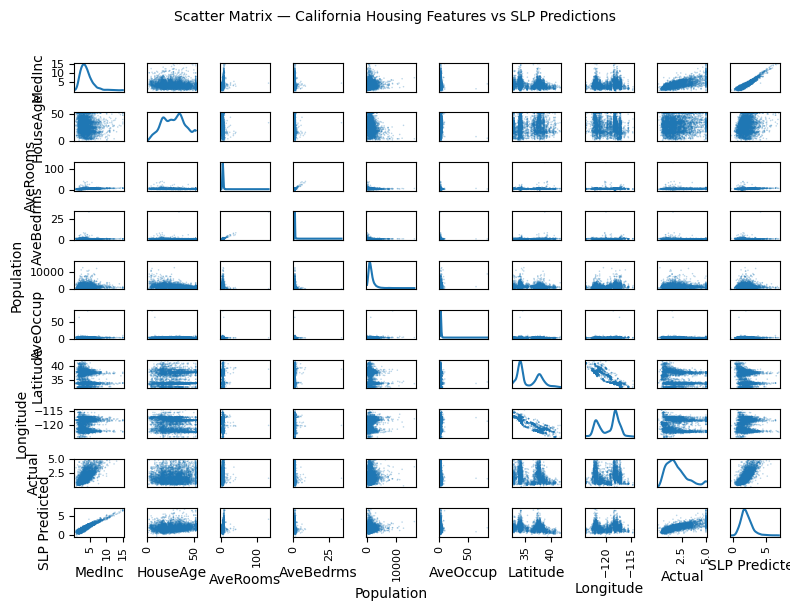

In [60]:
warnings.filterwarnings('ignore')

pd.plotting.scatter_matrix(corr_cal, figsize=(8, 6), diagonal='kde', alpha=0.3, s=5)
plt.suptitle('Scatter Matrix — California Housing Features vs SLP Predictions', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

warnings.filterwarnings('default')

Classification Model

SimpleSLPClassifier  Accuracy: 0.9825
Sklearn MLPClassifier Accuracy: 0.9737


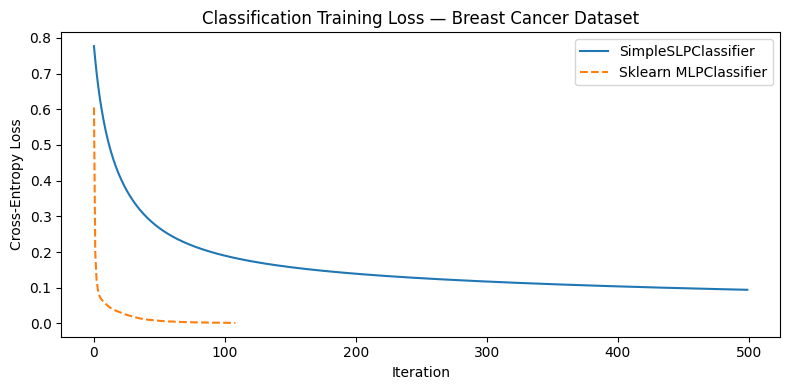

In [61]:
# Load and split
X_bc, y_bc = load_breast_cancer(return_X_y=True)
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)

scaler_bc = StandardScaler()
X_bc_train = scaler_bc.fit_transform(X_bc_train)
X_bc_test = scaler_bc.transform(X_bc_test)

# Fit our implementation
our_clf = SimpleSLPClassifier(hidden_layer_sizes=(64,), activation='relu', learning_rate=0.01, max_iter=500, random_state=42)
our_clf.fit(X_bc_train, y_bc_train)

# Fit sklearn MLPClassifier with matching hyperparameters
sklearn_clf = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', learning_rate_init=0.01, max_iter=500, random_state=42)
sklearn_clf.fit(X_bc_train, y_bc_train)

print(f'SimpleSLPClassifier  Accuracy: {our_clf.score(X_bc_test, y_bc_test):.4f}')
print(f'Sklearn MLPClassifier Accuracy: {sklearn_clf.score(X_bc_test, y_bc_test):.4f}')

# Plot training loss curves
plt.figure(figsize=(8, 4))
plt.plot(our_clf.loss_curve_, label='SimpleSLPClassifier')
plt.plot(sklearn_clf.loss_curve_, label='Sklearn MLPClassifier', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Cross-Entropy Loss')
plt.title('Classification Training Loss — Breast Cancer Dataset')
plt.legend()
plt.tight_layout()
plt.show()

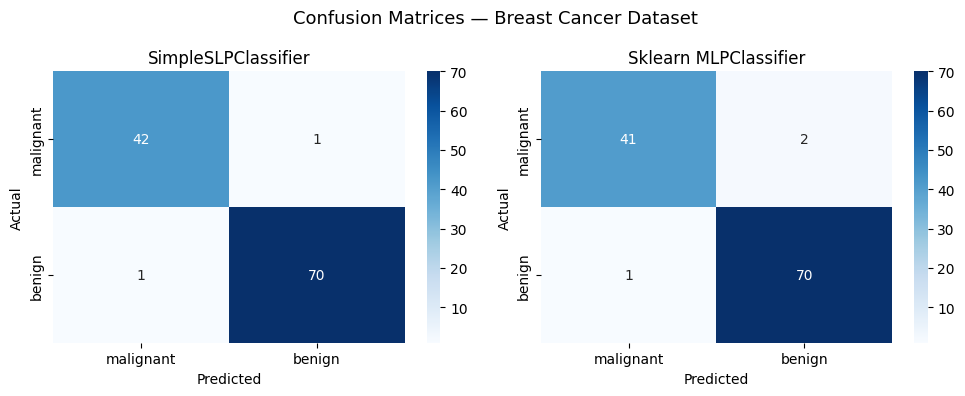

=== SimpleSLPClassifier ===


,precision,recall,f1-score,support
malignant,0.9767,0.9767,0.9767,43.0000
benign,0.9859,0.9859,0.9859,71.0000
accuracy,0.9825,0.9825,0.9825,0.9825
macro avg,0.9813,0.9813,0.9813,114.0000
weighted avg,0.9825,0.9825,0.9825,114.0000


=== Sklearn MLPClassifier ===


,precision,recall,f1-score,support
malignant,0.9762,0.9535,0.9647,43.0000
benign,0.9722,0.9859,0.9790,71.0000
accuracy,0.9737,0.9737,0.9737,0.9737
macro avg,0.9742,0.9697,0.9719,114.0000
weighted avg,0.9737,0.9737,0.9736,114.0000


In [62]:
target_names = load_breast_cancer().target_names  # ['malignant', 'benign']

y_pred_bc_our = our_clf.predict(X_bc_test)
y_pred_bc_sklearn = sklearn_clf.predict(X_bc_test)

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, label in zip(axes, [y_pred_bc_our, y_pred_bc_sklearn], ['SimpleSLPClassifier', 'Sklearn MLPClassifier']):
    cm = confusion_matrix(y_bc_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(label)

plt.suptitle('Confusion Matrices — Breast Cancer Dataset', fontsize=13)
plt.tight_layout()
plt.show()

# Classification metrics table
def clf_metrics(y_true, y_pred, names):
    report = classification_report(y_true, y_pred, target_names=names, output_dict=True)
    return pd.DataFrame(report).T.round(4)

print("=== SimpleSLPClassifier ===")
display(clf_metrics(y_bc_test, y_pred_bc_our, target_names))

print("=== Sklearn MLPClassifier ===")
display(clf_metrics(y_bc_test, y_pred_bc_sklearn, target_names))

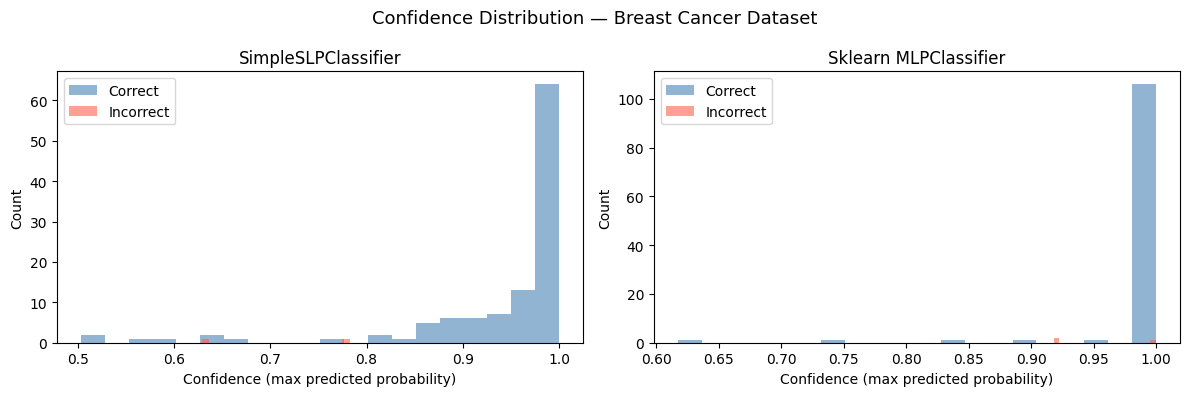

=== Misclassified Samples — SimpleSLPClassifier (2 of 114) ===


,True Label,Predicted,Confidence
0,malignant,benign,0.7826
1,benign,malignant,0.6288


=== Misclassified Samples — Sklearn MLPClassifier (3 of 114) ===


,True Label,Predicted,Confidence
0,malignant,benign,0.9995
1,benign,malignant,0.9209
2,malignant,benign,0.9183


In [63]:
# Confidence analysis — Breast Cancer Dataset
proba_bc_our = our_clf.predict_proba(X_bc_test)
proba_bc_sklearn = sklearn_clf.predict_proba(X_bc_test)

confidence_bc_our = proba_bc_our.max(axis=1)
confidence_bc_sklearn = proba_bc_sklearn.max(axis=1)

correct_bc_our = y_pred_bc_our == y_bc_test
correct_bc_sklearn = y_pred_bc_sklearn == y_bc_test

# Confidence histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, confidence, correct, label in zip(
    axes,
    [confidence_bc_our, confidence_bc_sklearn],
    [correct_bc_our, correct_bc_sklearn],
    ['SimpleSLPClassifier', 'Sklearn MLPClassifier'],
):
    ax.hist(confidence[correct], bins=20, alpha=0.6, label='Correct', color='steelblue')
    ax.hist(confidence[~correct], bins=20, alpha=0.6, label='Incorrect', color='tomato')
    ax.set_xlabel('Confidence (max predicted probability)')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend()

plt.suptitle('Confidence Distribution — Breast Cancer Dataset', fontsize=13)
plt.tight_layout()
plt.show()

# Misclassification tables
for label, y_pred, confidence, correct in [
    ('SimpleSLPClassifier', y_pred_bc_our, confidence_bc_our, correct_bc_our),
    ('Sklearn MLPClassifier', y_pred_bc_sklearn, confidence_bc_sklearn, correct_bc_sklearn),
]:
    misclassified_idx = np.where(~correct)[0]
    print(f"=== Misclassified Samples — {label} ({len(misclassified_idx)} of {len(y_bc_test)}) ===")
    if len(misclassified_idx) > 0:
        mc_df = pd.DataFrame({
            'True Label': target_names[y_bc_test[misclassified_idx]],
            'Predicted': target_names[y_pred[misclassified_idx]],
            'Confidence': confidence[misclassified_idx].round(4),
        }).sort_values('Confidence', ascending=False).reset_index(drop=True)
        display(mc_df)
    else:
        print("No misclassifications.")

SimpleSLPClassifier   Accuracy: 0.9028
Sklearn MLPClassifier Accuracy: 0.9806


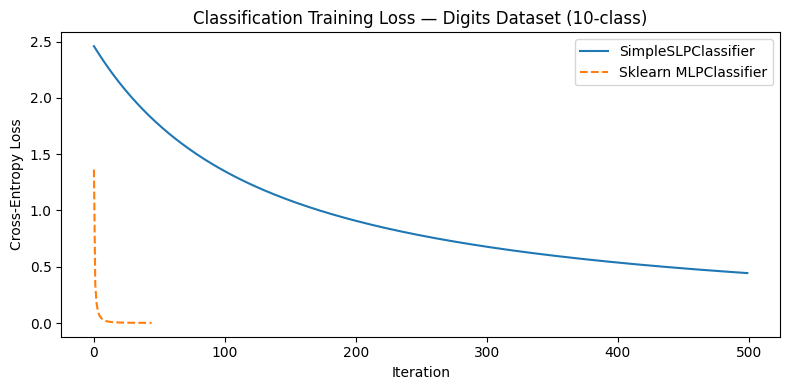

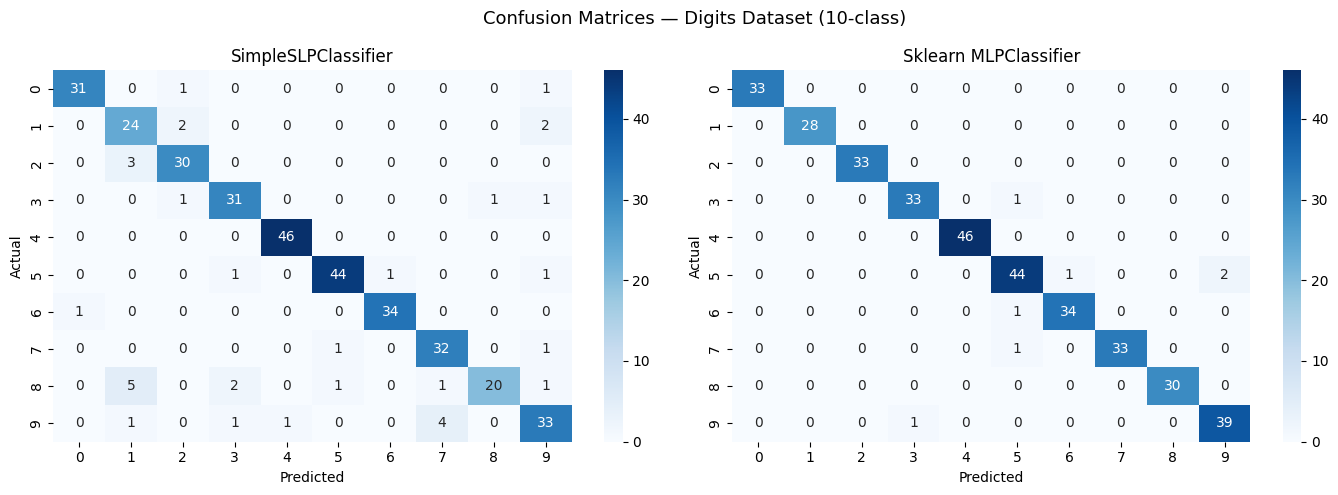

=== SimpleSLPClassifier ===


,precision,recall,f1-score,support
0,0.9688,0.9394,0.9538,33.0000
1,0.7273,0.8571,0.7869,28.0000
2,0.8824,0.9091,0.8955,33.0000
3,0.8857,0.9118,0.8986,34.0000
4,0.9787,1.0000,0.9892,46.0000
5,0.9565,0.9362,0.9462,47.0000
6,0.9714,0.9714,0.9714,35.0000
7,0.8649,0.9412,0.9014,34.0000
8,0.9524,0.6667,0.7843,30.0000
9,0.8250,0.8250,0.8250,40.0000


=== Sklearn MLPClassifier ===


,precision,recall,f1-score,support
0,1.0000,1.0000,1.0000,33.0000
1,1.0000,1.0000,1.0000,28.0000
2,1.0000,1.0000,1.0000,33.0000
3,0.9706,0.9706,0.9706,34.0000
4,1.0000,1.0000,1.0000,46.0000
5,0.9362,0.9362,0.9362,47.0000
6,0.9714,0.9714,0.9714,35.0000
7,1.0000,0.9706,0.9851,34.0000
8,1.0000,1.0000,1.0000,30.0000
9,0.9512,0.9750,0.9630,40.0000


In [64]:
digits = load_digits()
X_d, y_d = digits.data, digits.target
digit_target_names = [str(i) for i in digits.target_names]  # ['0'..'9']

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

scaler_d = StandardScaler()
X_d_train = scaler_d.fit_transform(X_d_train)
X_d_test = scaler_d.transform(X_d_test)

# Fit our implementation
our_digits = SimpleSLPClassifier(hidden_layer_sizes=(64,), activation='relu', learning_rate=0.01, max_iter=500, random_state=42)
our_digits.fit(X_d_train, y_d_train)

# Fit sklearn MLPClassifier with matching hyperparameters
sklearn_digits = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', learning_rate_init=0.01, max_iter=500, random_state=42)
sklearn_digits.fit(X_d_train, y_d_train)

y_pred_d_our = our_digits.predict(X_d_test)
y_pred_d_sklearn = sklearn_digits.predict(X_d_test)

print(f'SimpleSLPClassifier   Accuracy: {our_digits.score(X_d_test, y_d_test):.4f}')
print(f'Sklearn MLPClassifier Accuracy: {sklearn_digits.score(X_d_test, y_d_test):.4f}')

# Loss curves
plt.figure(figsize=(8, 4))
plt.plot(our_digits.loss_curve_, label='SimpleSLPClassifier')
plt.plot(sklearn_digits.loss_curve_, label='Sklearn MLPClassifier', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Cross-Entropy Loss')
plt.title('Classification Training Loss — Digits Dataset (10-class)')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, label in zip(axes, [y_pred_d_our, y_pred_d_sklearn], ['SimpleSLPClassifier', 'Sklearn MLPClassifier']):
    cm = confusion_matrix(y_d_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=digit_target_names, yticklabels=digit_target_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(label)

plt.suptitle('Confusion Matrices — Digits Dataset (10-class)', fontsize=13)
plt.tight_layout()
plt.show()

# Classification metrics tables
print("=== SimpleSLPClassifier ===")
display(clf_metrics(y_d_test, y_pred_d_our, digit_target_names))

print("=== Sklearn MLPClassifier ===")
display(clf_metrics(y_d_test, y_pred_d_sklearn, digit_target_names))

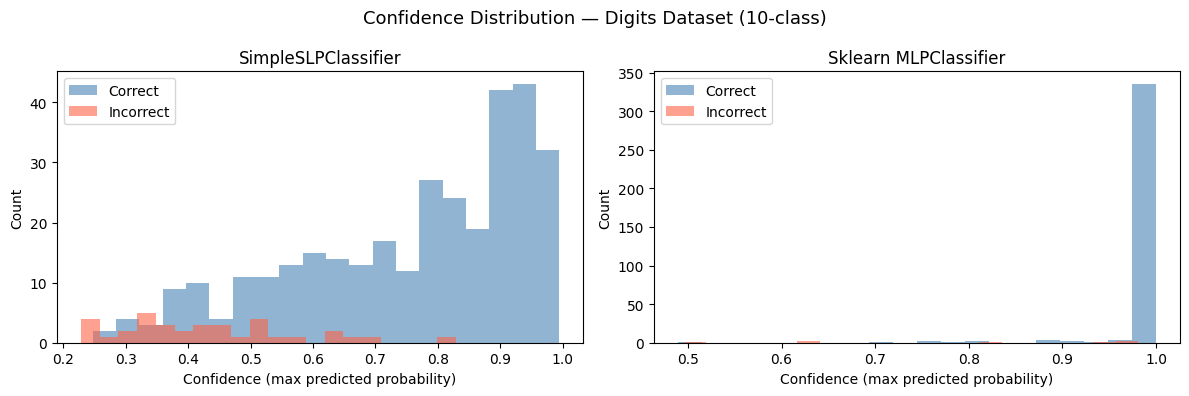

=== Misclassified Samples — SimpleSLPClassifier (35 of 360) ===


,True Label,Predicted,Confidence
0,3,2,0.8291
1,1,2,0.7071
2,6,0,0.6604
3,8,1,0.6207
4,1,9,0.6201
5,2,1,0.5683
6,8,1,0.5585
7,5,6,0.5265
8,8,1,0.5081
9,9,7,0.4999


=== Misclassified Samples — Sklearn MLPClassifier (7 of 360) ===


,True Label,Predicted,Confidence
0,3,5,0.9811
1,5,6,0.9740
2,5,9,0.9530
3,9,3,0.8155
4,6,5,0.6380
5,5,9,0.6332
6,7,5,0.4953


In [65]:
# Confidence analysis — Digits Dataset
proba_d_our = our_digits.predict_proba(X_d_test)
proba_d_sklearn = sklearn_digits.predict_proba(X_d_test)

confidence_d_our = proba_d_our.max(axis=1)
confidence_d_sklearn = proba_d_sklearn.max(axis=1)

correct_d_our = y_pred_d_our == y_d_test
correct_d_sklearn = y_pred_d_sklearn == y_d_test

# Confidence histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, confidence, correct, label in zip(
    axes,
    [confidence_d_our, confidence_d_sklearn],
    [correct_d_our, correct_d_sklearn],
    ['SimpleSLPClassifier', 'Sklearn MLPClassifier'],
):
    ax.hist(confidence[correct], bins=20, alpha=0.6, label='Correct', color='steelblue')
    ax.hist(confidence[~correct], bins=20, alpha=0.6, label='Incorrect', color='tomato')
    ax.set_xlabel('Confidence (max predicted probability)')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend()

plt.suptitle('Confidence Distribution — Digits Dataset (10-class)', fontsize=13)
plt.tight_layout()
plt.show()

# Misclassification tables
for label, y_pred, confidence, correct in [
    ('SimpleSLPClassifier', y_pred_d_our, confidence_d_our, correct_d_our),
    ('Sklearn MLPClassifier', y_pred_d_sklearn, confidence_d_sklearn, correct_d_sklearn),
]:
    misclassified_idx = np.where(~correct)[0]
    print(f"=== Misclassified Samples — {label} ({len(misclassified_idx)} of {len(y_d_test)}) ===")
    if len(misclassified_idx) > 0:
        mc_df = pd.DataFrame({
            'True Label': [digit_target_names[y_d_test[i]] for i in misclassified_idx],
            'Predicted': [digit_target_names[y_pred[i]] for i in misclassified_idx],
            'Confidence': confidence[misclassified_idx].round(4),
        }).sort_values('Confidence', ascending=False).reset_index(drop=True)
        display(mc_df)
    else:
        print("No misclassifications.")